In [49]:
import os
os.getcwd()

'/Users/theashen/Desktop/Project 1/archive'

In [50]:
import pandas as pd
import numpy as np

train = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None)
train = train.dropna(axis=1)

train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [51]:
cols = ["engine_id", "cycle"] + \
       [f"operation_setting_{i}" for i in range(1,4)] + \
       [f"sensor_{i}" for i in range(1,22)]

train.columns = cols

train.head()

,engine_id,cycle,operation_setting_1,operation_setting_2,operation_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [52]:
max_cycle = train.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

max_cycle.head()

,engine_id,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [53]:
train = train.merge(max_cycle, on='engine_id')

In [54]:
train['RUL'] = train['max_cycle'] - train['cycle']

In [55]:
threshold = 30

train['label'] = (train['RUL'] <= threshold).astype(int)

In [56]:
train[['engine_id', 'cycle', 'RUL', 'label']].head(20)

,engine_id,cycle,RUL,label
0,1,1,191,0
1,1,2,190,0
2,1,3,189,0
3,1,4,188,0
4,1,5,187,0
5,1,6,186,0
6,1,7,185,0
7,1,8,184,0
8,1,9,183,0
9,1,10,182,0


In [57]:
train['label'].value_counts()

label
0    17531
1     3100
Name: count, dtype: int64

In [58]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=['engine_id', 'cycle', 'RUL', 'label'])

y = train['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [59]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [60]:
y_pred = model.predict(X_test)

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3543
           1       0.88      0.85      0.87       584

    accuracy                           0.96      4127
   macro avg       0.93      0.92      0.92      4127
weighted avg       0.96      0.96      0.96      4127



In [62]:
model_balanced = LogisticRegression(
    max_iter = 1000,
    class_weight = 'balanced'
)

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      3543
           1       0.73      0.95      0.83       584

    accuracy                           0.94      4127
   macro avg       0.86      0.95      0.90      4127
weighted avg       0.95      0.94      0.95      4127



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_scaled_balanced = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced')
)

model_scaled_balanced.fit(X_train, y_train)
y_pred_scaled_balanced = model_scaled_balanced.predict(X_test)

print(classification_report(y_test, y_pred_scaled_balanced))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3543
           1       0.75      0.95      0.84       584

    accuracy                           0.95      4127
   macro avg       0.87      0.95      0.90      4127
weighted avg       0.96      0.95      0.95      4127



In [64]:
!pip install imbalanced-learn

In [65]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train_smote.value_counts())

label
0    13988
1    13988
Name: count, dtype: int64


In [66]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_smote = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3543
           1       0.77      0.95      0.85       584

    accuracy                           0.95      4127
   macro avg       0.88      0.95      0.91      4127
weighted avg       0.96      0.95      0.95      4127



In [67]:
!pip install xgboost

In [68]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3543
           1       0.90      0.89      0.90       584

    accuracy                           0.97      4127
   macro avg       0.94      0.94      0.94      4127
weighted avg       0.97      0.97      0.97      4127



/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [06:36:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [69]:
import numpy as np

scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

xgb_weighted = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

xgb_weighted.fit(X_train, y_train)

y_pred_xgb_weighted = xgb_weighted.predict(X_test)

print(classification_report(y_test, y_pred_xgb_weighted))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3543
           1       0.81      0.94      0.87       584

    accuracy                           0.96      4127
   macro avg       0.90      0.95      0.92      4127
weighted avg       0.96      0.96      0.96      4127



In [70]:
xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)

print(classification_report(y_test, y_pred_xgb_smote))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3543
           1       0.84      0.93      0.89       584

    accuracy                           0.97      4127
   macro avg       0.92      0.95      0.93      4127
weighted avg       0.97      0.97      0.97      4127



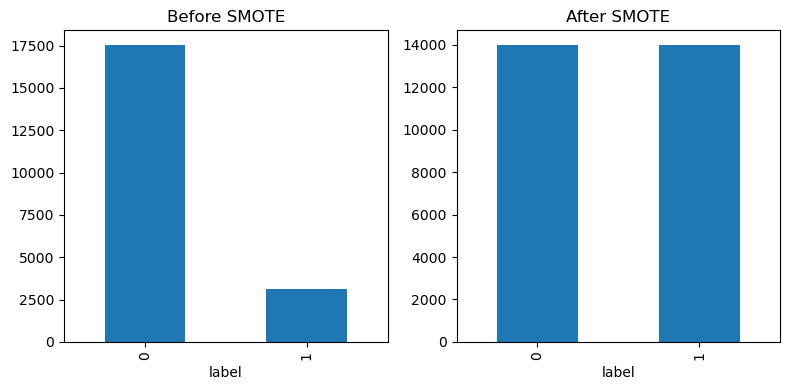

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(8,4))

train['label'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Before SMOTE')

import pandas as pd
pd.Series(y_train_smote).value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('After SMOTE')

plt.tight_layout()
plt.savefig('smote_comparison.png')